## Домашнее задание 2: сверточный классификатор.

### Оценивание и штрафы
### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [ ]:
def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [transforms.ToTensor(),
         # Переводим цвета пикселей в отрезок [-1, 1]
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(np.arange(len(trainvalset)), test_size=0.3,
                                            shuffle=True, random_state=0)
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                              shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader


In [ ]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64,
                                                         transform_train=transform)

100%|██████████| 170M/170M [00:04<00:00, 42.2MB/s]


Посмотрим на изображения:

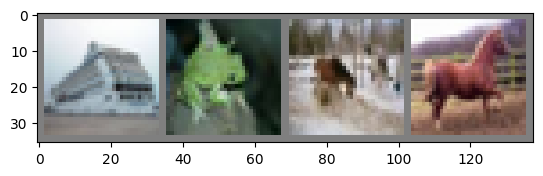

ship frog horse horse


In [ ]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [ ]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AvgPool2d(8)

        self.fc = nn.Linear(32 * 4 * 4, n_classes)

    def forward(self, x):
        identity = x
        if identity.shape[1] != 32:
            identity = F.pad(identity, (0,0,0,0,0,29))

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = F.relu(out + identity)

        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [ ]:
net = BasicBlockNet()
net

BasicBlockNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (fc): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [ ]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [ ]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [ ]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = F.cross_entropy(output, target)

            loss_log.append(loss.item())

            pred = output.argmax(dim=1)
            acc = (pred == target).float().mean()
            acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()                 # градиенты = 0
        output = model(data)                  # проход прямо
        loss = F.cross_entropy(output, target) # лосс
        loss.backward()                       # обратный проход
        optimizer.step()                      # шаг оптимизатора

        loss_log.append(loss.item())

        pred = output.argmax(dim=1)
        acc = (pred == target).float().mean()
        acc_log.append(acc.item())

    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [ ]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 1.472210187035897, train acc: 0.4752301514911477
 val loss: 1.280347651623665, val acc: 0.5592420212765957

Epoch 1
 train loss: 1.1734071976523948, train acc: 0.5903058893283935
 val loss: 1.2038101130343497, val acc: 0.5779920212765958

Epoch 2
 train loss: 1.0542454707557147, train acc: 0.6348385675733661
 val loss: 1.1502499412983023, val acc: 0.6019281914893617

Epoch 3
 train loss: 1.0008736980680575, train acc: 0.6507737007829781
 val loss: 1.0742007141417644, val acc: 0.6336657801841168

Epoch 4
 train loss: 0.971308679205844, train acc: 0.6606204297250542
 val loss: 0.9984295865322681, val acc: 0.6580452127659574

Epoch 5
 train loss: 0.9266267985486897, train acc: 0.6772615239432787
 val loss: 0.957628182908322, val acc: 0.6679299646235527

Epoch 6
 train loss: 0.9030361346614426, train acc: 0.6881121050505141
 val loss: 0.964412248134613, val acc: 0.6678856382978723

Epoch 7
 train loss: 0.8842534080719817, train acc: 0.6942821233320497
 val loss: 0.9019

Посчитайте точность на тестовой выборке:

In [ ]:
test_loss, test_acc = test(net, test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.8740
Test accuracy: 0.7064


Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

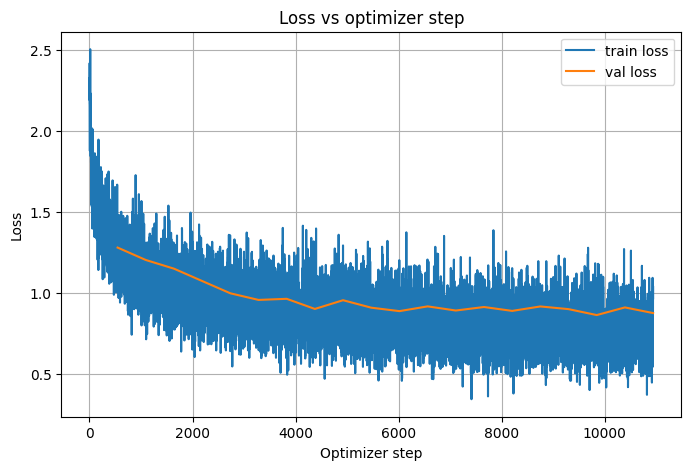

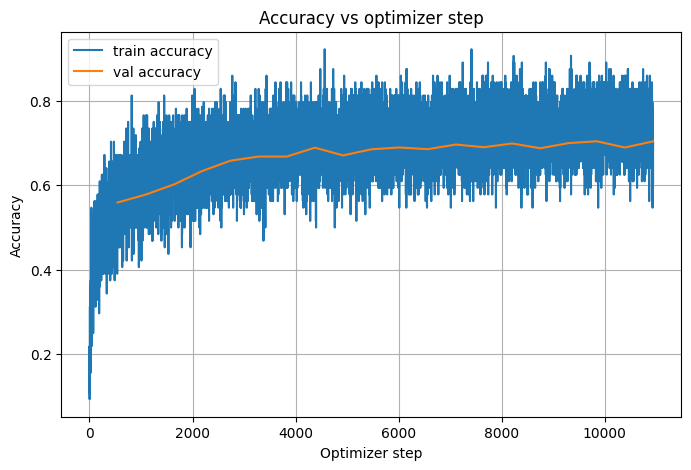

In [ ]:
steps_per_epoch = len(train_loader)

train_steps = np.arange(len(train_loss_log))

val_steps = np.arange(steps_per_epoch - 1,
                      steps_per_epoch * len(val_loss_log),
                      steps_per_epoch)

# лосс
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_loss_log, label='train loss')
plt.plot(val_steps, val_loss_log, label='val loss')
plt.xlabel('Optimizer step')
plt.ylabel('Loss')
plt.title('Loss vs optimizer step')
plt.legend()
plt.grid(True)
plt.show()

# accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_acc_log, label='train accuracy')
plt.plot(val_steps, val_acc_log, label='val accuracy')
plt.xlabel('Optimizer step')
plt.ylabel('Accuracy')
plt.title('Accuracy vs optimizer step')
plt.legend()
plt.grid(True)
plt.show()


## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.490861398646339, train acc: 0.4653018086440385
 val loss: 1.2591617487846536, val acc: 0.5532358156873824

Epoch 1
 train loss: 1.175662054658154, train acc: 0.5865189997544018
 val loss: 1.142461918516362, val acc: 0.6036569148936171

Epoch 2
 train loss: 1.0532823358636887, train acc: 0.6295989488117002
 val loss: 1.1332653370309382, val acc: 0.6001551418862444

Epoch 3
 train loss: 0.9965379165121144, train acc: 0.6517163424648794
 val loss: 1.0107270392965764, val acc: 0.6441710993330529

Epoch 4
 train loss: 0.961094012426066, train acc: 0.6658437255313671
 val loss: 0.9688050921927107, val acc: 0.6629210994598713

Epoch 5
 train loss: 0.9364062542235394, train acc: 0.675066107369864
 val loss: 0.9868355527837226, val acc: 0.6567597518575953

Epoch 6
 train loss: 0.9100449679102715, train acc: 0.684863867881747
 val loss: 0.9484640362414908, val acc: 0.6769281914893617

Epoch 7
 train loss: 0.8823755481561315, train acc: 0.6934088535021167
 val loss: 0.92776

Посчитайте точность на тестовой выборке:

In [ ]:
test_loss, test_acc = test(net, test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.8216
Test accuracy: 0.7139


**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [ ]:
net_small_lr = BasicBlockNet().to(device)
optimizer_small = optim.SGD(net_small_lr.parameters(), lr=0.001, momentum=0.9)

tr_loss_s, tr_acc_s, val_loss_s, val_acc_s = train(
    net_small_lr, optimizer_small, 20, train_loader, val_loader
)

test_loss_s, test_acc_s = test(net_small_lr, test_loader)
print("Test accuracy with lr=0.001 from start:", test_acc_s)

Epoch 0
 train loss: 1.8250595076210538, train acc: 0.35973818232416016
 val loss: 1.6206587410987692, val acc: 0.4343528369639782

Epoch 1
 train loss: 1.5367243865290334, train acc: 0.4598418321099534
 val loss: 1.4645925329086629, val acc: 0.47898936170212764

Epoch 2
 train loss: 1.424397155397335, train acc: 0.49933892662825924
 val loss: 1.3824360664854658, val acc: 0.5155141844394359

Epoch 3
 train loss: 1.3567413932880492, train acc: 0.5246882346038191
 val loss: 1.3378872658344025, val acc: 0.5316267731341909

Epoch 4
 train loss: 1.298216471724362, train acc: 0.5483603747714808
 val loss: 1.2843907493226072, val acc: 0.5478945035883721

Epoch 5
 train loss: 1.245136078576501, train acc: 0.5674743732978919
 val loss: 1.2167380358310456, val acc: 0.5742242908224147

Epoch 6
 train loss: 1.2003845963661153, train acc: 0.5819200509427016
 val loss: 1.1808103480237595, val acc: 0.5857269503968827

Epoch 7
 train loss: 1.1623623467014739, train acc: 0.5956230413107375
 val loss: 1

**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

In [ ]:
net_cos = BasicBlockNet().to(device)
optimizer_cos = optim.SGD(net_cos.parameters(), lr=0.1, momentum=0.9)

scheduler_cos = optim.lr_scheduler.CosineAnnealingLR(optimizer_cos, T_max=20)

tr_loss_c, tr_acc_c, val_loss_c, val_acc_c = train(
    net_cos, optimizer_cos, 20, train_loader, val_loader, scheduler_cos
)

test_loss_c, test_acc_c = test(net_cos, test_loader)
print("Test acc Cosine:", test_acc_c)

# cosine decay

Epoch 0
 train loss: 1.505479237279247, train acc: 0.46497535258803985
 val loss: 1.2738377048614178, val acc: 0.5531471631628402

Epoch 1
 train loss: 1.1855973491285139, train acc: 0.5799001045593178
 val loss: 1.1449881705831975, val acc: 0.6001329787234042

Epoch 2
 train loss: 1.0682595128115178, train acc: 0.6265996344782535
 val loss: 1.0370862504269214, val acc: 0.6373226952045522

Epoch 3
 train loss: 1.0061584411417108, train acc: 0.6485864455782735
 val loss: 1.0304566185525124, val acc: 0.6500664893617021

Epoch 4
 train loss: 0.9657201921700124, train acc: 0.6631218987147595
 val loss: 1.0601789299477922, val acc: 0.6366799646235527

Epoch 5
 train loss: 0.9247807684938476, train acc: 0.6765025138201182
 val loss: 0.9619978744932945, val acc: 0.6654920212765958

Epoch 6
 train loss: 0.8946550605066079, train acc: 0.68748367726258
 val loss: 0.9188349830343369, val acc: 0.6861702127659575

Epoch 7
 train loss: 0.8761787282701384, train acc: 0.6951023440474348
 val loss: 0.9

In [ ]:
net_exp = BasicBlockNet().to(device)
optimizer_exp = optim.SGD(net_exp.parameters(), lr=0.1, momentum=0.9)

scheduler_exp = optim.lr_scheduler.ExponentialLR(optimizer_exp, gamma=0.95)

tr_loss_e, tr_acc_e, val_loss_e, val_acc_e = train(
    net_exp, optimizer_exp, 20, train_loader, val_loader, scheduler_exp
)

test_loss_e, test_acc_e = test(net_exp, test_loader)
print("Test acc Exponential:", test_acc_e)

# lr уменьшается на гамму каждую эпоху

Epoch 0
 train loss: 1.5130597653728952, train acc: 0.45494499219618945
 val loss: 1.3386164726094996, val acc: 0.5338874114320633

Epoch 1
 train loss: 1.2073645564494229, train acc: 0.5775496213266139
 val loss: 1.198754977672658, val acc: 0.5751329787234043

Epoch 2
 train loss: 1.0708207133919054, train acc: 0.6286114194929273
 val loss: 1.0361895502881802, val acc: 0.640625

Epoch 3
 train loss: 0.9977527568065706, train acc: 0.6563112105922245
 val loss: 0.9805294485802346, val acc: 0.6643838654173181

Epoch 4
 train loss: 0.9494533996477423, train acc: 0.6688593628201668
 val loss: 0.9568168843046148, val acc: 0.6688829787234043

Epoch 5
 train loss: 0.9134637522741035, train acc: 0.6825133847580096
 val loss: 0.9748319029808045, val acc: 0.660970744680851

Epoch 6
 train loss: 0.8886898171967083, train acc: 0.6923111452698926
 val loss: 0.9484900573466687, val acc: 0.676595744680851

Epoch 7
 train loss: 0.8719049135335403, train acc: 0.696767269584335
 val loss: 0.965413245748

In [ ]:
net_one = BasicBlockNet().to(device)
optimizer_one = optim.SGD(net_one.parameters(), lr=0.1, momentum=0.9)

scheduler_one = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_one,
    max_lr=0.1,
    steps_per_epoch=len(train_loader),
    epochs=20
)

tr_loss_o, tr_acc_o, val_loss_o, val_acc_o = train(
    net_one, optimizer_one, 20, train_loader, val_loader, scheduler_one
)

test_loss_o, test_acc_o = test(net_one, test_loader)
print("Test acc OneCycle:", test_acc_o)

# что-то умное. 1cycle learning rate policy changes the learning rate after every batch

Epoch 0
 train loss: 1.5415507317461088, train acc: 0.45123971663619744
 val loss: 1.3126100098833124, val acc: 0.5340647163543295

Epoch 1
 train loss: 1.269138778149537, train acc: 0.551404576959732
 val loss: 1.1852270740143795, val acc: 0.584796099333053

Epoch 2
 train loss: 1.1350171689141604, train acc: 0.600148537477148
 val loss: 1.126458284702707, val acc: 0.603346631374765

Epoch 3
 train loss: 1.0604240904124607, train acc: 0.6292928963954095
 val loss: 1.038705628983518, val acc: 0.632690602921425

Epoch 4
 train loss: 1.0041478796022683, train acc: 0.6485211544106604
 val loss: 0.991128738890303, val acc: 0.6527925531914893

Epoch 5
 train loss: 0.9704174654357394, train acc: 0.6638523440474348
 val loss: 0.9531494670725883, val acc: 0.6633865248649679

Epoch 6
 train loss: 0.9385666426618531, train acc: 0.6718709194246114
 val loss: 0.9823307729781943, val acc: 0.6580452127659574

Epoch 7
 train loss: 0.9140533122763556, train acc: 0.6805097611120458
 val loss: 0.9257846

Your answers here:

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

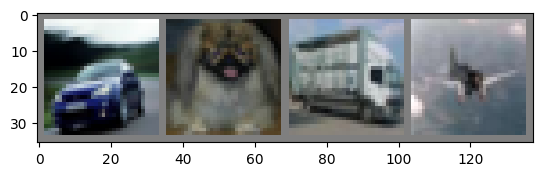

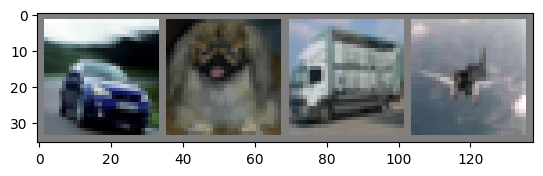

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [ ]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.4718970390516835, train acc: 0.4758259336952753
 val loss: 1.2604320736641579, val acc: 0.5599290780564572

Epoch 1
 train loss: 1.1671271895141881, train acc: 0.5912893379628114
 val loss: 1.0889888844591507, val acc: 0.6199689718002969

Epoch 2
 train loss: 1.0490369595165008, train acc: 0.6364177984119116
 val loss: 1.0654347642939141, val acc: 0.6230718085106383

Epoch 3
 train loss: 0.9977815162111244, train acc: 0.6542626992004227
 val loss: 1.051433977421294, val acc: 0.638497340425532

Epoch 4
 train loss: 0.9567232457767675, train acc: 0.6684880191272966
 val loss: 0.9997954969710492, val acc: 0.654942376055616

Epoch 5
 train loss: 0.927945820570428, train acc: 0.6786530426476948
 val loss: 0.9132761554515109, val acc: 0.6813164893617021

Epoch 6
 train loss: 0.9125216876784887, train acc: 0.6825582725038476
 val loss: 0.9103291694154131, val acc: 0.6867686170212766

Epoch 7
 train loss: 0.8950987473484368, train acc: 0.6883814311986431
 val loss: 0.906

Посчитайте точность на тестовой выборке:

In [ ]:
test_loss_aug, test_acc_aug = test(net, test_loader)
print(f"Test accuracy with hflip: {test_acc_aug:.4f}")

Test accuracy with hflip: 0.7253


**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [ ]:
transforms.RandomCrop(32, padding=4)

RandomCrop(size=(32, 32), padding=4)

In [ ]:
transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)

In [ ]:
transforms.RandomRotation(15)

RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)

In [ ]:
transforms.GaussianBlur(kernel_size=3)

GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))

In [ ]:
# flip + кроп

transform_a = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64,
    transform_train=transform_a
)

net_a = BasicBlockNet().to(device)
opt_a = optim.SGD(net_a.parameters(), lr=0.1, momentum=0.9)
sch_a = optim.lr_scheduler.MultiStepLR(opt_a, milestones=[10, 15], gamma=0.1)

tr_loss_a, tr_acc_a, val_loss_a, val_acc_a = train(
    net_a, opt_a, 20, train_loader, val_loader, sch_a
)

test_loss_a, test_acc_a = test(net_a, test_loader)
print("Test acc (crop + flip):", test_acc_a)


Epoch 0
 train loss: 1.667204598186221, train acc: 0.3937181705639611
 val loss: 1.5886961612295598, val acc: 0.4336436170212766

Epoch 1
 train loss: 1.4096631086286722, train acc: 0.49369531869888306
 val loss: 1.3909505544824803, val acc: 0.4971631206096487

Epoch 2
 train loss: 1.2664431360783481, train acc: 0.550845521023766
 val loss: 1.190148352562113, val acc: 0.5726507093044038

Epoch 3
 train loss: 1.1871640175526494, train acc: 0.5807284866434129
 val loss: 1.2866696948700762, val acc: 0.5522163120990103

Epoch 4
 train loss: 1.1425560943823192, train acc: 0.5951007117518995
 val loss: 1.2013633410981361, val acc: 0.5775709220703612

Epoch 5
 train loss: 1.1161472908539571, train acc: 0.6076611060329068
 val loss: 1.0885589216617828, val acc: 0.6164450356300841

Epoch 6
 train loss: 1.090844514492007, train acc: 0.6198297531992687
 val loss: 1.1018931634882663, val acc: 0.6120345744680851

Epoch 7
 train loss: 1.074332540606232, train acc: 0.6240532776337437
 val loss: 1.044

In [ ]:
# флип и поворот

transform_c = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


Your answers here: